In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')

In [26]:
df = pd.read_csv('bank_marketing/bank.csv.xls.final')

columns_to_drop = ['day', 'month', 'contact', 'duration', 'default'] 
df = df.drop(columns_to_drop, axis=1)
display(df.head())

le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'])

X = df.drop('deposit', axis=1)
y = df['deposit']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

,age,education,balance,loan,campaign,pdays,previous,poutcome,deposit,marital_married,...,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,housing_yes
0,59,secondary,0.104371,no,1,-1,0,unknown,yes,True,...,False,False,False,False,False,False,False,False,False,True
1,56,secondary,0.078273,no,1,-1,0,unknown,yes,True,...,False,False,False,False,False,False,False,False,False,False
2,41,secondary,0.092185,no,1,-1,0,unknown,yes,True,...,False,False,False,False,False,False,True,False,False,True
3,55,secondary,0.105882,no,1,-1,0,unknown,yes,True,...,False,False,False,False,True,False,False,False,False,True
4,54,tertiary,0.079851,no,2,-1,0,unknown,yes,True,...,False,False,False,False,False,False,False,False,False,False


Размер обучающей выборки: (7813, 26)
Размер тестовой выборки: (3349, 26)


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, rf_predictions)

print("Результаты Случайного леса:")
print(f"Точность на тестовой выборке (Accuracy): {test_accuracy:.4f}")
print(f"OOB Accuracy (Точность на OOB-данных): {rf_model.oob_score_:.4f}")
print(f"OOB Error (Ошибка OOB): {1 - rf_model.oob_score_:.4f}")

Результаты Случайного леса:
Точность на тестовой выборке (Accuracy): 0.6602
OOB Accuracy (Точность на OOB-данных): 0.6572
OOB Error (Ошибка OOB): 0.3428


In [29]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

print("Модели AdaBoost и Градиентного бустинга успешно обучены!")

Модели AdaBoost и Градиентного бустинга успешно обучены!


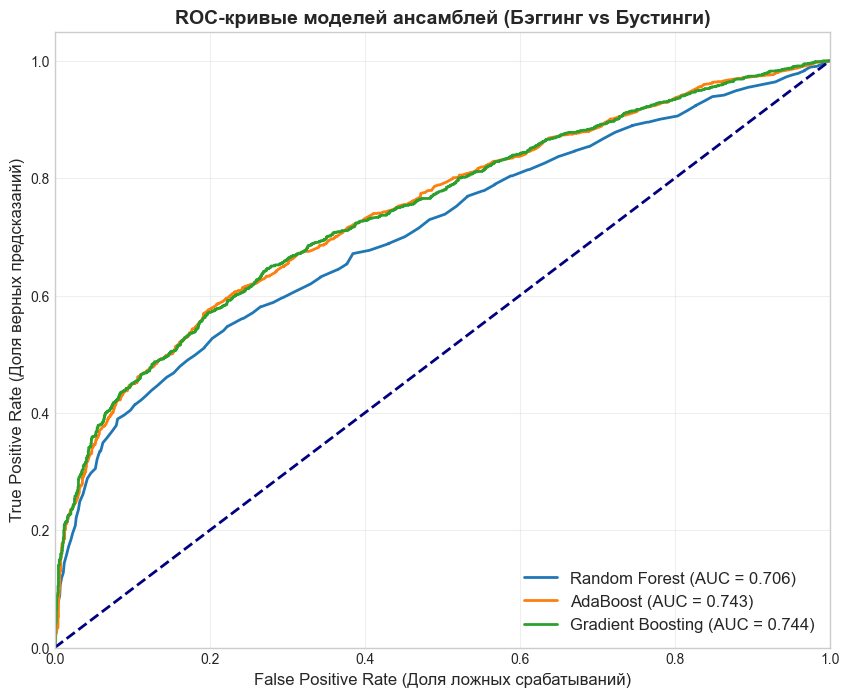

In [30]:
from sklearn.metrics import roc_curve, auc

models = {
    'Random Forest': rf_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr) 
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложных срабатываний)', fontsize=12)
plt.ylabel('True Positive Rate (Доля верных предсказаний)', fontsize=12)
plt.title('ROC-кривые моделей ансамблей (Бэггинг vs Бустинги)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
-